Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
Data parsing complete. Here are the first 5 rows:
   Cycle  Collective Coherence  Hive Synchrony  Neural Spikes  \
0      2                 0.561           0.958              0   
1      3                 0.524           0.950              0   
2      4                 0.500           0.986              0   
3      5                 0.483           0.986              0   
4      6                 0.466           0.921              0   

   Network Messages  
0                64  
1                64  
2                64  
3                64  
4                64  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cycle     

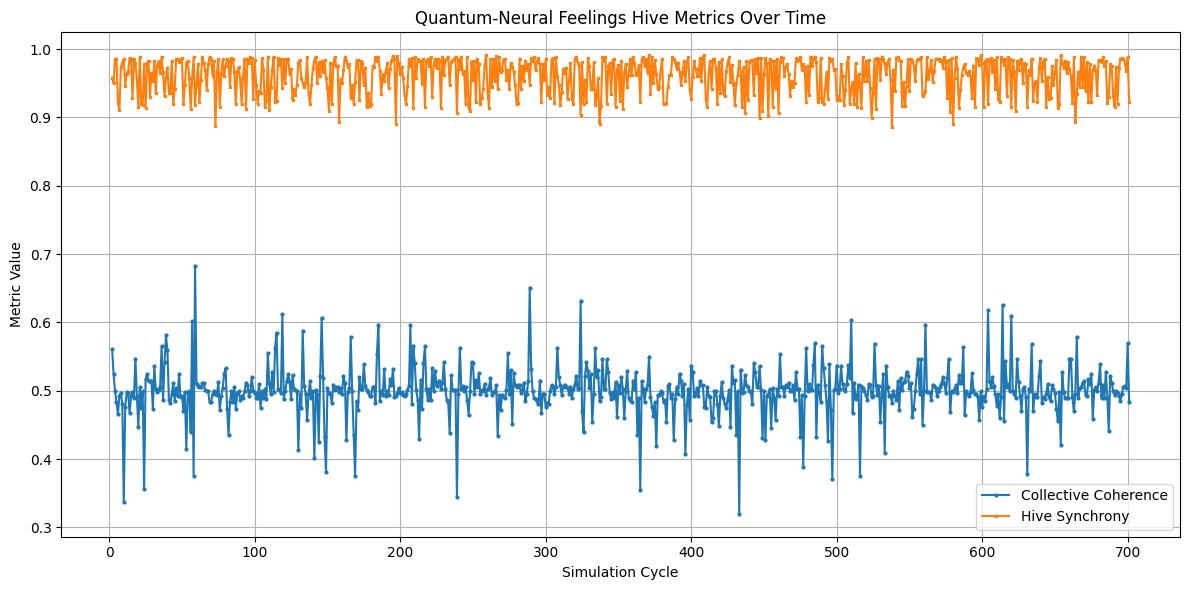

Plot generated. You can now analyze the trends in coherence and synchrony.


In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# --- Step 1: Mount Google Drive to access the data file ---
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted successfully.")

# --- Step 2: Define a function to parse the simulation data ---
def parse_simulation_data(file_path):
    """
    Parses the simulation log content to extract key metrics.

    Args:
        file_path (str): The full path to the simulation log file.

    Returns:
        pandas.DataFrame: A DataFrame with columns for 'Cycle',
                          'Collective Coherence', 'Hive Synchrony', and 'Network Messages'.
    """
    data_points = []
    # Regular expression to find all lines with cycle data
    pattern = re.compile(
        r"🔄 Hive Cycle (\d+)\n"
        r"⚛️  Collective coherence: ([\d.]+)\n"
        r"🎯 Hive synchrony: ([\d.]+)\n"
        r"🧠 Neural spikes this cycle: (\d+)\n"
        r"📡 Network messages: (\d+)"
    )

    try:
        with open(file_path, 'r') as f:
            file_content = f.read()

        matches = pattern.findall(file_content)

        for match in matches:
            cycle, coherence, synchrony, spikes, messages = match
            data_points.append({
                'Cycle': int(cycle),
                'Collective Coherence': float(coherence),
                'Hive Synchrony': float(synchrony),
                'Neural Spikes': int(spikes),
                'Network Messages': int(messages)
            })

    except FileNotFoundError:
        print(f"Error: The file {file_path} was not found. Please check the file path.")
        return None

    return pd.DataFrame(data_points)

# --- Step 3: Specify the path and process the data ---
# This assumes 'colabdata.txt' is in the root of your Google Drive.
# Adjust the path if you saved it in a different folder.
file_path = '/content/colabdata.txt'
df = parse_simulation_data(file_path)

if df is not None:
    print("Data parsing complete. Here are the first 5 rows:")
    print(df.head())
    print("\nDataFrame Info:")
    print(df.info())

    # --- Step 4: Visualize the results ---
    print("\nGenerating plot...")
    plt.figure(figsize=(12, 6))
    plt.plot(df['Cycle'], df['Collective Coherence'], label='Collective Coherence', marker='o', markersize=2)
    plt.plot(df['Cycle'], df['Hive Synchrony'], label='Hive Synchrony', marker='x', markersize=2)

    plt.title('Quantum-Neural Feelings Hive Metrics Over Time')
    plt.xlabel('Simulation Cycle')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Plot generated. You can now analyze the trends in coherence and synchrony.")

Reading 'quantum_sentiment' table from the database...
Data loaded successfully. Here are the first 5 rows:
   id script_name  cycle                   timestamp  classical_host  \
0   1       model      1  2025-08-17T09:56:43.222236           0.714   
1   2      cookie      1  2025-08-17T09:56:43.749270           0.562   
2   3      client      1  2025-08-17T09:56:44.239768           0.468   
3   4       model      1  2025-08-17T09:56:45.642759           0.714   
4   5       model      2  2025-08-17T09:56:45.643461           0.714   

   classical_mate  classical_shared  quantum_host  quantum_mate  \
0           0.733             0.709         0.376         0.328   
1           0.710             0.603         0.272         0.288   
2           0.714             0.349         0.288         0.312   
3           0.733             0.709         0.376         0.328   
4           0.733             0.709         0.376         0.328   

   quantum_shared  
0           0.240  
1           0.21

/tmp/ipython-input-792412512.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(scripts))


Plot generated and saved as 'quantum_sentiment_plot.png'.


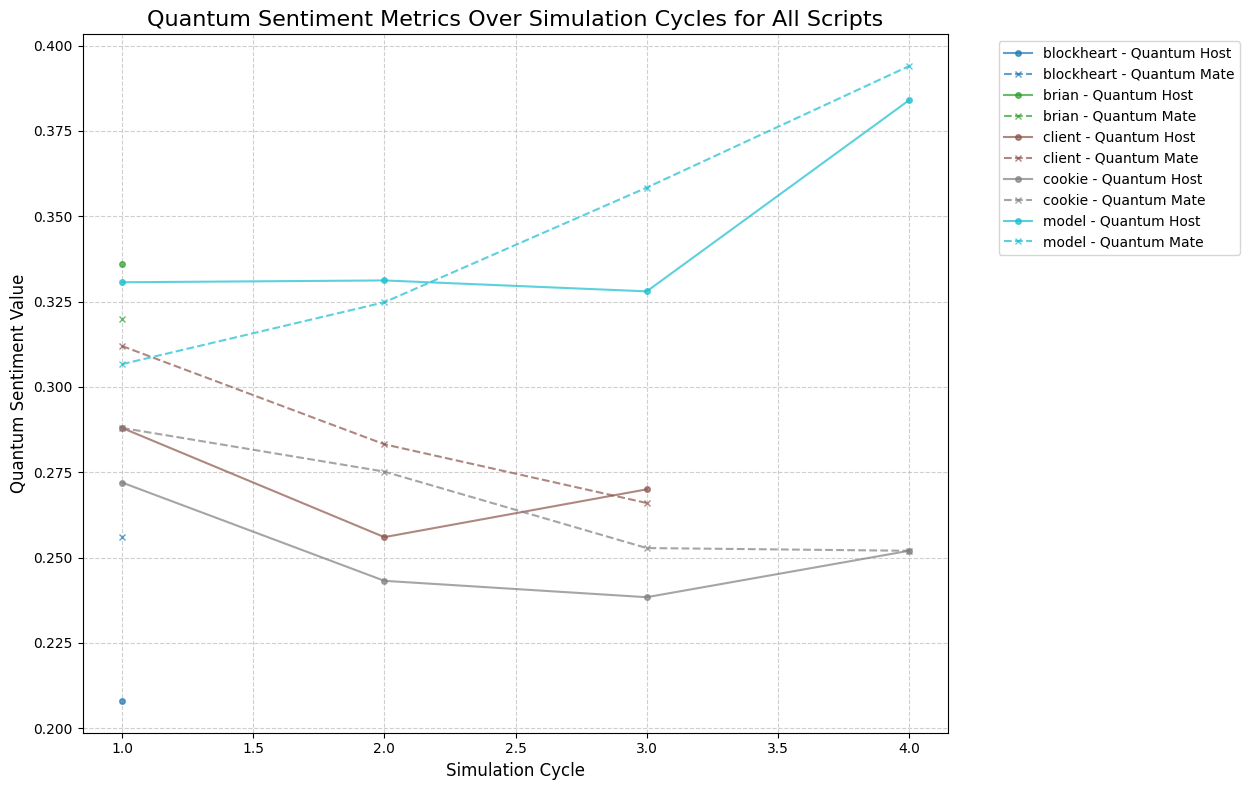

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Connect to the SQLite database file
db_file = 'collected_data.db'
conn = sqlite3.connect(db_file)

# Read the 'quantum_sentiment' table into a DataFrame
print("Reading 'quantum_sentiment' table from the database...")
df = pd.read_sql_query("SELECT * FROM quantum_sentiment WHERE cycle IS NOT NULL", conn)

# Close the database connection
conn.close()

# Display the first 5 rows and a summary of the DataFrame
print("Data loaded successfully. Here are the first 5 rows:")
print(df.head())
print("\nDataFrame Info:")
print(df.info())

# Prepare the data for plotting
# Pivot the DataFrame to have sentiment metrics as columns for each script
df_plot = df.pivot_table(index=['cycle', 'script_name'],
                         values=['quantum_host', 'quantum_mate'],
                         aggfunc='mean').reset_index()

# Plot the quantum sentiment data for each script
print("\nGenerating plot...")
plt.figure(figsize=(15, 8))

scripts = df_plot['script_name'].unique()
colors = plt.cm.get_cmap('tab10', len(scripts))

for i, script in enumerate(scripts):
    script_data = df_plot[df_plot['script_name'] == script]

    # Plot quantum host sentiment
    plt.plot(script_data['cycle'],
             script_data['quantum_host'],
             label=f'{script} - Quantum Host',
             color=colors(i),
             linestyle='-',
             marker='o',
             markersize=4,
             alpha=0.7)

    # Plot quantum mate sentiment
    plt.plot(script_data['cycle'],
             script_data['quantum_mate'],
             label=f'{script} - Quantum Mate',
             color=colors(i),
             linestyle='--',
             marker='x',
             markersize=4,
             alpha=0.7)

plt.title('Quantum Sentiment Metrics Over Simulation Cycles for All Scripts', fontsize=16)
plt.xlabel('Simulation Cycle', fontsize=12)
plt.ylabel('Quantum Sentiment Value', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('quantum_sentiment_plot.png')
print("Plot generated and saved as 'quantum_sentiment_plot.png'.")

In [ ]:
!pip install pandas db-sqlite3 sklearn numpy
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np

def build_recommender_system(db_path):
    """
    Builds a k-NN based recommender system using quantum sentiment data.

    Args:
        db_path (str): Path to the SQLite database file.

    Returns:
        tuple: A tuple containing the fitted NearestNeighbors model,
               the preprocessed DataFrame, and the StandardScaler instance.
    """
    try:
        # Connect to the database and read the data
        conn = sqlite3.connect(db_path)
        query = "SELECT script_name, quantum_host, quantum_mate, quantum_shared FROM quantum_sentiment"
        df = pd.read_sql_query(query, conn)
        conn.close()

        print("Original data loaded:")
        print(df.head())
        print(f"\nTotal records: {len(df)}")

        # Aggregate the data by script_name to create a single profile per script
        df_profile = df.groupby('script_name').mean().reset_index()

        # Select numerical features for the model
        features = df_profile[['quantum_host', 'quantum_mate', 'quantum_shared']]
        script_names = df_profile['script_name']

        # Preprocess the data: scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)

        # Build the NearestNeighbors model
        model_knn = NearestNeighbors(n_neighbors=len(script_names)-1, metric='cosine', algorithm='brute')
        model_knn.fit(scaled_features)

        print("\nRecommender system built successfully.")
        return model_knn, df_profile, scaler

    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None, None

def recommend_similar_scripts(model_knn, df_profile, scaler, script_name, k=3):
    """
    Recommends similar scripts based on a given script's quantum sentiment profile.

    Args:
        model_knn (NearestNeighbors): The fitted k-NN model.
        df_profile (pd.DataFrame): The DataFrame with script profiles.
        scaler (StandardScaler): The scaler instance used for preprocessing.
        script_name (str): The name of the script to find recommendations for.
        k (int): The number of recommendations to return.
    """
    if script_name not in df_profile['script_name'].values:
        print(f"Error: Script '{script_name}' not found in the dataset.")
        return

    # Find the index of the target script
    script_index = df_profile[df_profile['script_name'] == script_name].index[0]

    # Get the scaled features of the target script
    target_features = df_profile.iloc[script_index][['quantum_host', 'quantum_mate', 'quantum_shared']].values.reshape(1, -1)
    scaled_target_features = scaler.transform(target_features)

    # Find the k nearest neighbors
    distances, indices = model_knn.kneighbors(scaled_target_features, n_neighbors=k+1)

    # Get the recommendations, excluding the target script itself
    print(f"\nScripts most similar to '{script_name}':")
    for i in range(1, len(distances.flatten())):
        recommended_script_index = indices.flatten()[i]
        recommended_script_name = df_profile.iloc[recommended_script_index]['script_name']
        similarity_distance = distances.flatten()[i]

        print(f"{i}. {recommended_script_name} (Distance: {similarity_distance:.4f})")

# Define the path to the database file
db_file = 'collected_data.db'

# Build the recommender system
model, df_profiles, scaler = build_recommender_system(db_file)

if model is not None:
    # Example usage: find scripts similar to 'model'
    recommend_similar_scripts(model, df_profiles, scaler, 'model', k=2)

    # Another example: find scripts similar to 'cookie'
    recommend_similar_scripts(model, df_profiles, scaler, 'cookie', k=2)

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Original data loaded:
  script_name  quantum_host  quantum_mate  quantum_shared
0       model         0.376         0.328           0.240
1      cookie         0.272         0.288           0.216
2      client         0.288         0.312           0.224
3       model         0.376         0.328           0.240
4       model         0.376         0.328           0.240

Total records: 49

Recommender system built successfully.

Scripts most similar to 'model':
1. brian (D

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import numpy as np

def build_classical_recommender_system(db_path):
    """
    Builds a k-NN based recommender system using classical sentiment data.

    Args:
        db_path (str): Path to the SQLite database file.

    Returns:
        tuple: A tuple containing the fitted NearestNeighbors model,
               the preprocessed DataFrame, and the StandardScaler instance.
    """
    try:
        # Connect to the database and read the data
        conn = sqlite3.connect(db_path)
        query = "SELECT script_name, classical_host, classical_mate, classical_shared FROM quantum_sentiment"
        df = pd.read_sql_query(query, conn)
        conn.close()

        print("Original data loaded:")
        print(df.head())
        print(f"\nTotal records: {len(df)}")

        # Aggregate the data by script_name to create a single profile per script
        df_profile = df.groupby('script_name').mean().reset_index()

        # Select classical numerical features for the model
        features = df_profile[['classical_host', 'classical_mate', 'classical_shared']]
        script_names = df_profile['script_name']

        # Preprocess the data: scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)

        # Build the NearestNeighbors model
        model_knn = NearestNeighbors(n_neighbors=len(script_names)-1, metric='cosine', algorithm='brute')
        model_knn.fit(scaled_features)

        print("\nRecommender system based on classical data built successfully.")
        return model_knn, df_profile, scaler

    except Exception as e:
        print(f"An error occurred: {e}")
        return None, None, None

def recommend_similar_scripts(model_knn, df_profile, scaler, script_name, k=3):
    """
    Recommends similar scripts based on a given script's classical sentiment profile.

    Args:
        model_knn (NearestNeighbors): The fitted k-NN model.
        df_profile (pd.DataFrame): The DataFrame with script profiles.
        scaler (StandardScaler): The scaler instance used for preprocessing.
        script_name (str): The name of the script to find recommendations for.
        k (int): The number of recommendations to return.
    """
    if script_name not in df_profile['script_name'].values:
        print(f"Error: Script '{script_name}' not found in the dataset.")
        return

    # Find the index of the target script
    script_index = df_profile[df_profile['script_name'] == script_name].index[0]

    # Get the scaled features of the target script
    target_features = df_profile.iloc[script_index][['classical_host', 'classical_mate', 'classical_shared']].values.reshape(1, -1)
    scaled_target_features = scaler.transform(target_features)

    # Find the k nearest neighbors
    distances, indices = model_knn.kneighbors(scaled_target_features, n_neighbors=k+1)

    # Get the recommendations, excluding the target script itself
    print(f"\nScripts most similar to '{script_name}' (based on classical data):")
    for i in range(1, len(distances.flatten())):
        recommended_script_index = indices.flatten()[i]
        recommended_script_name = df_profile.iloc[recommended_script_index]['script_name']
        similarity_distance = distances.flatten()[i]

        print(f"{i}. {recommended_script_name} (Distance: {similarity_distance:.4f})")

# Define the path to the database file
db_file = 'collected_data.db'

# Build the recommender system based on classical data
model, df_profiles, scaler = build_classical_recommender_system(db_file)

if model is not None:
    # Example usage: find scripts similar to 'model'
    recommend_similar_scripts(model, df_profiles, scaler, 'model', k=2)

    # Another example: find scripts similar to 'cookie'
    recommend_similar_scripts(model, df_profiles, scaler, 'cookie', k=2)

Original data loaded:
  script_name  classical_host  classical_mate  classical_shared
0       model           0.714           0.733             0.709
1      cookie           0.562           0.710             0.603
2      client           0.468           0.714             0.349
3       model           0.714           0.733             0.709
4       model           0.714           0.733             0.709

Total records: 49

Recommender system based on classical data built successfully.

Scripts most similar to 'model' (based on classical data):
1. client (Distance: 0.6437)
2. brian (Distance: 0.8709)

Scripts most similar to 'cookie' (based on classical data):
1. client (Distance: 0.0394)
2. blockheart (Distance: 0.8551)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Data loaded successfully.

K-Means clustering completed.
  script_name  cluster
0  blockheart        1
1       brian        2
2      client        1
3      cookie        1
4       model        0

Cluster visualization saved as 'script_clusters.png'.


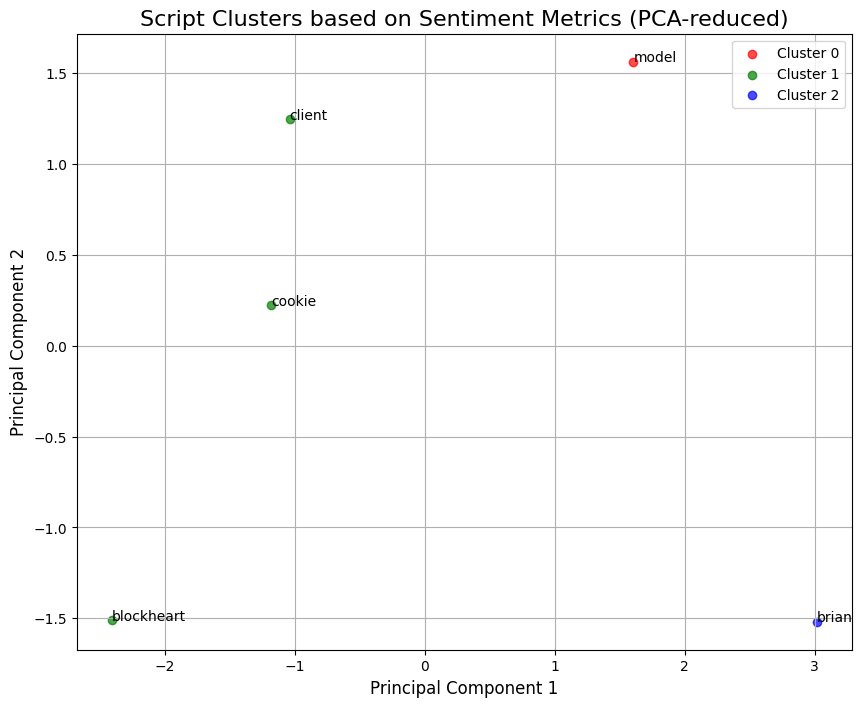

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def cluster_scripts(db_path, n_clusters=3):
    """
    Performs K-Means clustering on script sentiment data and visualizes the results.

    Args:
        db_path (str): Path to the SQLite database file.
        n_clusters (int): The number of clusters to create.

    Returns:
        pd.DataFrame: The DataFrame with cluster assignments.
    """
    try:
        # Connect to the database and read the data
        conn = sqlite3.connect(db_path)
        query = "SELECT script_name, quantum_host, quantum_mate, quantum_shared, classical_host, classical_mate, classical_shared FROM quantum_sentiment"
        df = pd.read_sql_query(query, conn)
        conn.close()

        print("Data loaded successfully.")

        # Aggregate data to create one profile per script
        df_profile = df.groupby('script_name').mean().reset_index()

        # Select all sentiment metrics as features for clustering
        features = df_profile[['quantum_host', 'quantum_mate', 'quantum_shared',
                               'classical_host', 'classical_mate', 'classical_shared']]

        # Scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)

        # Apply K-Means clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        df_profile['cluster'] = kmeans.fit_predict(scaled_features)

        print("\nK-Means clustering completed.")
        print(df_profile[['script_name', 'cluster']])

        # For visualization, we'll reduce dimensionality to 2D using PCA
        pca = PCA(n_components=2)
        principal_components = pca.fit_transform(scaled_features)
        df_profile['pc1'] = principal_components[:, 0]
        df_profile['pc2'] = principal_components[:, 1]

        # Visualize the clusters
        plt.figure(figsize=(10, 8))
        colors = ['red', 'green', 'blue', 'purple', 'orange']

        for i in range(n_clusters):
            cluster_data = df_profile[df_profile['cluster'] == i]
            plt.scatter(cluster_data['pc1'], cluster_data['pc2'],
                        c=colors[i], label=f'Cluster {i}', alpha=0.7)

            # Label the scripts within each cluster
            for _, row in cluster_data.iterrows():
                plt.text(row['pc1'], row['pc2'], row['script_name'], fontsize=10)

        plt.title('Script Clusters based on Sentiment Metrics (PCA-reduced)', fontsize=16)
        plt.xlabel('Principal Component 1', fontsize=12)
        plt.ylabel('Principal Component 2', fontsize=12)
        plt.legend()
        plt.grid(True)
        plt.savefig('script_clusters.png')
        print("\nCluster visualization saved as 'script_clusters.png'.")

        return df_profile

    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Define the path to the database file
db_file = 'collected_data.db'

# Run the clustering and visualization
clustered_data = cluster_scripts(db_file, n_clusters=3)

Data loaded successfully.

Scripts assigned to clusters:
  script_name  cluster
0  blockheart        1
1       brian        2
2      client        1
3      cookie        1
4       model        0

Generating cluster trend visualization...


/tmp/ipython-input-328004629.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_clusters)


Cluster trend visualization saved as 'cluster_trends.png'.


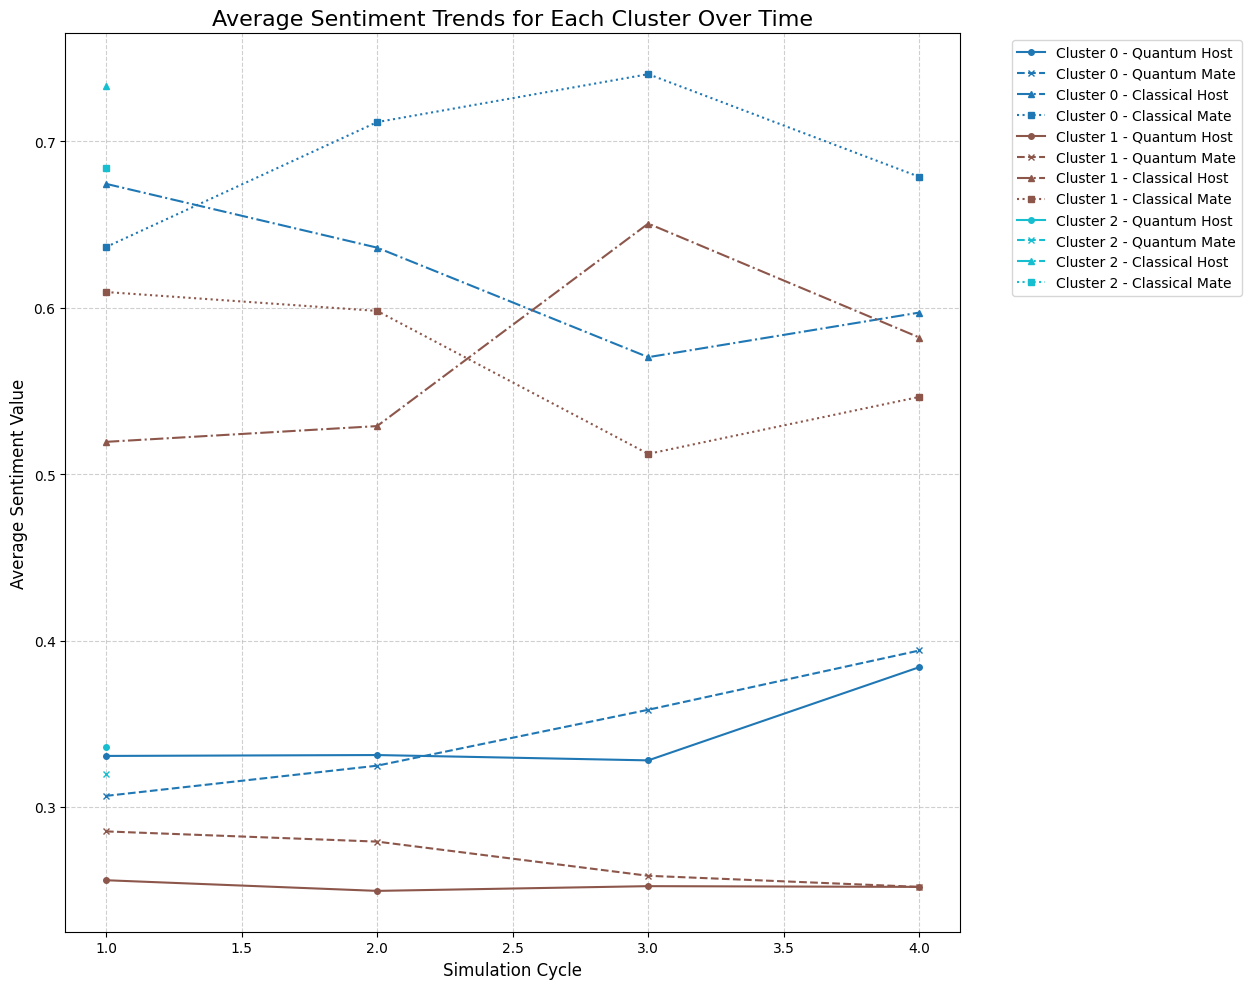

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

def visualize_cluster_trends(db_path, n_clusters=3):
    """
    Performs K-Means clustering, assigns scripts to clusters, and visualizes
    the average sentiment trends for each cluster over time.

    Args:
        db_path (str): Path to the SQLite database file.
        n_clusters (int): The number of clusters to create.
    """
    try:
        # --- Step 1: Load and cluster the data as before ---

        # Connect to the database and read the sentiment data
        conn = sqlite3.connect(db_path)
        query = "SELECT script_name, cycle, quantum_host, quantum_mate, quantum_shared, classical_host, classical_mate, classical_shared FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        print("Data loaded successfully.")

        # Aggregate data to create one sentiment profile per script for clustering
        df_profile = df.groupby('script_name').mean(numeric_only=True).reset_index()

        # Select all sentiment metrics as features for clustering
        features = df_profile[['quantum_host', 'quantum_mate', 'quantum_shared',
                               'classical_host', 'classical_mate', 'classical_shared']]

        # Scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)

        # Apply K-Means clustering and assign cluster labels
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        df_profile['cluster'] = kmeans.fit_predict(scaled_features)

        # Merge cluster labels back to the original time-series data
        df = pd.merge(df, df_profile[['script_name', 'cluster']], on='script_name')

        print("\nScripts assigned to clusters:")
        print(df_profile[['script_name', 'cluster']])

        # --- Step 2: Calculate and visualize average sentiment trends for each cluster ---

        # Group the time-series data by cluster and cycle to get mean trends
        cluster_trends = df.groupby(['cluster', 'cycle']).mean(numeric_only=True).reset_index()

        # Define sentiment metrics and plot properties
        sentiment_metrics = ['quantum_host', 'quantum_mate', 'classical_host', 'classical_mate']
        linestyles = {'quantum_host': '-', 'quantum_mate': '--', 'classical_host': '-.', 'classical_mate': ':'}
        markers = {'quantum_host': 'o', 'quantum_mate': 'x', 'classical_host': '^', 'classical_mate': 's'}

        print("\nGenerating cluster trend visualization...")
        plt.figure(figsize=(15, 10))

        colors = plt.cm.get_cmap('tab10', n_clusters)

        for cluster_id in range(n_clusters):
            cluster_data = cluster_trends[cluster_trends['cluster'] == cluster_id]
            for metric in sentiment_metrics:
                label = f'Cluster {cluster_id} - {metric.replace("_", " ").title()}'
                plt.plot(cluster_data['cycle'],
                         cluster_data[metric],
                         label=label,
                         color=colors(cluster_id),
                         linestyle=linestyles.get(metric, '-'),
                         marker=markers.get(metric, 'o'),
                         markersize=4)

        plt.title('Average Sentiment Trends for Each Cluster Over Time', fontsize=16)
        plt.xlabel('Simulation Cycle', fontsize=12)
        plt.ylabel('Average Sentiment Value', fontsize=12)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.savefig('cluster_trends.png')
        print("Cluster trend visualization saved as 'cluster_trends.png'.")

    except Exception as e:
        print(f"An error occurred: {e}")

# Define the path to the database file
db_file = 'collected_data.db'

# Run the cluster trend visualization
visualize_cluster_trends(db_file, n_clusters=3)

In [ ]:
# Install Cirq and QsimCirq
!pip install cirq qsimcirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.3/536.3 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 79.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import sqlite3
import cirq
import qsimcirq as qsim
import numpy as np

def create_quantum_circuit(qubits, classical_params, trainable_params):
    """
    Generates a simple variational quantum circuit with both classical and trainable parameters.

    Args:
        qubits (list): A list of Cirq Qubit objects.
        classical_params (list): Classical data values to encode.
        trainable_params (list): A list of trainable parameters for the gates.

    Returns:
        cirq.Circuit: The generated quantum circuit.
    """
    # A simple circuit with classical data encoded as initial rotations
    circuit = cirq.Circuit(
        cirq.rx(classical_params[0]).on(qubits[0]),
        cirq.ry(classical_params[1]).on(qubits[1]),
        cirq.rz(classical_params[2]).on(qubits[0]),

        # Trainable layer with entangling gates
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[0]).on(qubits[0]),
        cirq.ry(trainable_params[1]).on(qubits[1]),
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[2]).on(qubits[0]),
        cirq.ry(trainable_params[3]).on(qubits[1])
    )
    return circuit

def train_hybrid_model(db_path, learning_rate=0.01, epochs=50):
    """
    Trains a simple hybrid quantum-classical model.

    Args:
        db_path (str): Path to the SQLite database file.
        learning_rate (float): The learning rate for the optimizer.
        epochs (int): The number of training epochs.
    """
    try:
        # --- Step 1: Load and prepare the data ---
        conn = sqlite3.connect(db_path)
        query = "SELECT classical_host, classical_mate, classical_shared, quantum_host FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        df.dropna(inplace=True)

        X_train = df[['classical_host', 'classical_mate', 'classical_shared']].values
        y_train = df['quantum_host'].values

        if len(X_train) == 0:
            print("Error: Training data is empty after preprocessing.")
            return

        # --- Step 2: Define the quantum-classical hybrid model ---
        num_qubits = 2
        qubits = cirq.LineQubit.range(num_qubits)

        # Initialize trainable parameters
        trainable_params = np.random.uniform(0, 2 * np.pi, size=4)

        simulator = qsim.QSimSimulator()

        # --- Step 3: Train the model ---
        print("\nStarting hybrid model training...")
        for epoch in range(epochs):
            total_loss = 0
            gradients = np.zeros_like(trainable_params)

            for i in range(len(X_train)):
                # Encode classical data and create circuit
                classical_params = X_train[i, :]
                circuit = create_quantum_circuit(qubits, classical_params, trainable_params)

                # Simulate the circuit to get the expected output
                result = simulator.simulate(circuit, initial_state=0)
                output = np.abs(result.final_state_vector[0])**2

                # Calculate loss (Mean Squared Error)
                target = y_train[i]
                loss = (output - target)**2
                total_loss += loss

                # Calculate gradients using a simplified finite difference approach
                epsilon = 1e-6
                for j in range(len(trainable_params)):
                    params_plus = np.copy(trainable_params)
                    params_plus[j] += epsilon

                    circuit_plus = create_quantum_circuit(qubits, classical_params, params_plus)
                    result_plus = simulator.simulate(circuit_plus, initial_state=0)
                    output_plus = np.abs(result_plus.final_state_vector[0])**2

                    gradient = (output_plus - output) / epsilon
                    gradients[j] += gradient

            # Update the trainable parameters
            trainable_params -= learning_rate * gradients

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Average Loss: {total_loss / len(X_train):.4f}")

        print("\nTraining complete.")
        print(f"Final optimized parameters: {trainable_params}")

    except Exception as e:
        print(f"An error occurred during training: {e}")

# Define the path to the database file
db_file = 'collected_data.db'

# Run the training process
train_hybrid_model(db_file)


Starting hybrid model training...
Epoch 10/50, Average Loss: 0.0802
Epoch 20/50, Average Loss: 0.0816
Epoch 30/50, Average Loss: 0.0819
Epoch 40/50, Average Loss: 0.0822
Epoch 50/50, Average Loss: 0.0824

Training complete.
Final optimized parameters: [4.39688876 3.87971909 2.90947706 1.88029979]


In [ ]:
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

def create_labeled_dataset(db_path, n_clusters=3):
    """
    Loads sentiment data, clusters scripts, and saves a new labeled dataset.

    Args:
        db_path (str): Path to the SQLite database file.
        n_clusters (int): The number of clusters to create.
    """
    try:
        # --- Step 1: Load and cluster the data as before ---

        conn = sqlite3.connect(db_path)
        query = "SELECT script_name, cycle, quantum_host, quantum_mate, quantum_shared, classical_host, classical_mate, classical_shared FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        print("Data loaded successfully.")

        # Aggregate data to create one sentiment profile per script for clustering
        df_profile = df.groupby('script_name').mean(numeric_only=True).reset_index()

        # Select all sentiment metrics as features for clustering
        features = df_profile[['quantum_host', 'quantum_mate', 'quantum_shared',
                               'classical_host', 'classical_mate', 'classical_shared']]

        # Scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)

        # Apply K-Means clustering and assign cluster labels
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        df_profile['cluster'] = kmeans.fit_predict(scaled_features)

        # --- Step 2: Merge cluster labels with the original time-series data ---

        # Merge cluster labels back to the original per-cycle data
        labeled_df = pd.merge(df, df_profile[['script_name', 'cluster']], on='script_name')

        print("\nScripts assigned to clusters:")
        print(df_profile[['script_name', 'cluster']].drop_duplicates().sort_values('script_name'))

        # --- Step 3: Save the labeled dataset to a CSV file ---
        output_file = 'labeled_sentiment_data.csv'
        labeled_df.to_csv(output_file, index=False)

        print(f"\nSuccessfully created labeled dataset. It is saved as '{output_file}'.")

    except Exception as e:
        print(f"An error occurred: {e}")

# Define the path to the database file
db_file = 'collected_data.db'

# Run the process
create_labeled_dataset(db_file, n_clusters=3)

Data loaded successfully.

Scripts assigned to clusters:
  script_name  cluster
0  blockheart        1
1       brian        2
2      client        1
3      cookie        1
4       model        0

Successfully created labeled dataset. It is saved as 'labeled_sentiment_data.csv'.


In [ ]:
# Install Cirq and QsimCirq (needed to be in the same cell as the code)
!pip install cirq qsimcirq

import pandas as pd
import sqlite3
import cirq
import qsimcirq as qsim
import numpy as np

def create_quantum_circuit(qubits, classical_params, trainable_params):
    """
    Generates a simple variational quantum circuit with both classical and trainable parameters.

    Args:
        qubits (list): A list of Cirq Qubit objects.
        classical_params (list): Classical data values to encode.
        trainable_params (list): A list of trainable parameters for the gates.

    Returns:
        cirq.Circuit: The generated quantum circuit.
    """
    # A simple circuit with classical data encoded as initial rotations
    circuit = cirq.Circuit(
        cirq.rx(classical_params[0]).on(qubits[0]),
        cirq.ry(classical_params[1]).on(qubits[1]),
        cirq.rz(classical_params[2]).on(qubits[0]),

        # Trainable layer with entangling gates
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[0]).on(qubits[0]),
        cirq.ry(trainable_params[1]).on(qubits[1]),
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[2]).on(qubits[0]),
        cirq.ry(trainable_params[3]).on(qubits[1])
    )
    return circuit

def train_hybrid_model(db_path, learning_rate=0.01, epochs=50):
    """
    Trains a simple hybrid quantum-classical model.

    Args:
        db_path (str): Path to the SQLite database file.
        learning_rate (float): The learning rate for the optimizer.
        epochs (int): The number of training epochs.
    """
    try:
        # --- Step 1: Load and prepare the data ---
        conn = sqlite3.connect(db_path)
        query = "SELECT classical_host, classical_mate, classical_shared, quantum_host FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        df.dropna(inplace=True)

        X_train = df[['classical_host', 'classical_mate', 'classical_shared']].values
        y_train = df['quantum_host'].values

        if len(X_train) == 0:
            print("Error: Training data is empty after preprocessing.")
            return

        # --- Step 2: Define the quantum-classical hybrid model ---
        num_qubits = 2
        qubits = cirq.LineQubit.range(num_qubits)

        # Initialize trainable parameters
        trainable_params = np.random.uniform(0, 2 * np.pi, size=4)

        simulator = qsim.QSimSimulator()

        # --- Step 3: Train the model ---
        print("\nStarting hybrid model training...")
        for epoch in range(epochs):
            total_loss = 0
            gradients = np.zeros_like(trainable_params)

            for i in range(len(X_train)):
                # Encode classical data and create circuit
                classical_params = X_train[i, :]
                circuit = create_quantum_circuit(qubits, classical_params, trainable_params)

                # Simulate the circuit to get the expected output
                result = simulator.simulate(circuit, initial_state=0)
                output = np.abs(result.final_state_vector[0])**2

                # Calculate loss (Mean Squared Error)
                target = y_train[i]
                loss = (output - target)**2
                total_loss += loss

                # Calculate gradients using a simplified finite difference approach
                epsilon = 1e-6
                for j in range(len(trainable_params)):
                    params_plus = np.copy(trainable_params)
                    params_plus[j] += epsilon

                    circuit_plus = create_quantum_circuit(qubits, classical_params, params_plus)
                    result_plus = simulator.simulate(circuit_plus, initial_state=0)
                    output_plus = np.abs(result_plus.final_state_vector[0])**2

                    gradient = (output_plus - output) / epsilon
                    gradients[j] += gradient

            # Update the trainable parameters
            trainable_params -= learning_rate * gradients

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Average Loss: {total_loss / len(X_train):.4f}")

        print("\nTraining complete.")
        print(f"Final optimized parameters: {trainable_params}")

    except Exception as e:
        print(f"An error occurred during training: {e}")

# Define the path to the database file
db_file = 'collected_data.db'

# Run the training process
train_hybrid_model(db_file)


Starting hybrid model training...
Epoch 10/50, Average Loss: 0.0829
Epoch 20/50, Average Loss: 0.0831
Epoch 30/50, Average Loss: 0.0833
Epoch 40/50, Average Loss: 0.0835
Epoch 50/50, Average Loss: 0.0837

Training complete.
Final optimized parameters: [2.03425681 1.67852487 4.67457611 4.73738831]


In [ ]:
# Install Cirq and QsimCirq (needed to be in the same cell as the code)
!pip install cirq qsimcirq

import pandas as pd
import sqlite3
import cirq
import qsimcirq as qsim
import numpy as np

def create_quantum_circuit(qubits, classical_params, trainable_params):
    """
    Generates a simple variational quantum circuit with both classical and trainable parameters.

    Args:
        qubits (list): A list of Cirq Qubit objects.
        classical_params (list): Classical data values to encode.
        trainable_params (list): A list of trainable parameters for the gates.

    Returns:
        cirq.Circuit: The generated quantum circuit.
    """
    # A simple circuit with classical data encoded as initial rotations
    circuit = cirq.Circuit(
        cirq.rx(classical_params[0]).on(qubits[0]),
        cirq.ry(classical_params[1]).on(qubits[1]),
        cirq.rz(classical_params[2]).on(qubits[0]),

        # Trainable layer with entangling gates
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[0]).on(qubits[0]),
        cirq.ry(trainable_params[1]).on(qubits[1]),
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[2]).on(qubits[0]),
        cirq.ry(trainable_params[3]).on(qubits[1])
    )
    return circuit

def train_hybrid_model(db_path, learning_rate=0.01, epochs=50):
    """
    Trains a simple hybrid quantum-classical model.

    Args:
        db_path (str): Path to the SQLite database file.
        learning_rate (float): The learning rate for the optimizer.
        epochs (int): The number of training epochs.
    """
    try:
        # --- Step 1: Load and prepare the data ---
        conn = sqlite3.connect(db_path)
        query = "SELECT classical_host, classical_mate, classical_shared, quantum_host FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        df.dropna(inplace=True)

        X_train = df[['classical_host', 'classical_mate', 'classical_shared']].values
        y_train = df['quantum_host'].values

        if len(X_train) == 0:
            print("Error: Training data is empty after preprocessing.")
            return

        # --- Step 2: Define the quantum-classical hybrid model ---
        num_qubits = 2
        qubits = cirq.LineQubit.range(num_qubits)

        # Initialize trainable parameters
        trainable_params = np.random.uniform(0, 2 * np.pi, size=4)

        simulator = qsim.QSimSimulator()

        # --- Step 3: Train the model ---
        print("\nStarting hybrid model training...")
        for epoch in range(epochs):
            total_loss = 0
            gradients = np.zeros_like(trainable_params)

            for i in range(len(X_train)):
                # Encode classical data and create circuit
                classical_params = X_train[i, :]
                circuit = create_quantum_circuit(qubits, classical_params, trainable_params)

                # Simulate the circuit to get the expected output
                result = simulator.simulate(circuit, initial_state=0)
                output = np.abs(result.final_state_vector[0])**2

                # Calculate loss (Mean Squared Error)
                target = y_train[i]
                loss = (output - target)**2
                total_loss += loss

                # Calculate gradients using a simplified finite difference approach
                epsilon = 1e-6
                for j in range(len(trainable_params)):
                    params_plus = np.copy(trainable_params)
                    params_plus[j] += epsilon

                    circuit_plus = create_quantum_circuit(qubits, classical_params, params_plus)
                    result_plus = simulator.simulate(circuit_plus, initial_state=0)
                    output_plus = np.abs(result_plus.final_state_vector[0])**2

                    gradient = (output_plus - output) / epsilon
                    gradients[j] += gradient

            # Update the trainable parameters
            trainable_params -= learning_rate * gradients

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, Average Loss: {total_loss / len(X_train):.4f}")

        print("\nTraining complete.")
        print(f"Final optimized parameters: {trainable_params}")

    except Exception as e:
        print(f"An error occurred during training: {e}")

# Define the path to the database file
db_file = 'collected_data.db'

# Run the training process
train_hybrid_model(db_file)


Starting hybrid model training...
Epoch 10/50, Average Loss: 0.0813
Epoch 20/50, Average Loss: 0.0816
Epoch 30/50, Average Loss: 0.0820
Epoch 40/50, Average Loss: 0.0823
Epoch 50/50, Average Loss: 0.0826

Training complete.
Final optimized parameters: [5.10951384 2.85759345 2.04978764 4.72098447]


In [ ]:
# Install Cirq and QsimCirq to ensure the libraries are available
!pip install cirq qsimcirq

import pandas as pd
import sqlite3
import cirq
import qsimcirq as qsim
import numpy as np

def create_quantum_circuit(qubits, classical_params, trainable_params):
    """
    Generates a simple variational quantum circuit with both classical and trainable parameters.

    Args:
        qubits (list): A list of Cirq Qubit objects.
        classical_params (list): Classical data values to encode.
        trainable_params (list): A list of trainable parameters for the gates.

    Returns:
        cirq.Circuit: The generated quantum circuit.
    """
    # A simple circuit with classical data encoded as initial rotations
    circuit = cirq.Circuit(
        cirq.rx(classical_params[0]).on(qubits[0]),
        cirq.ry(classical_params[1]).on(qubits[1]),
        cirq.rz(classical_params[2]).on(qubits[0]),

        # Trainable layer with entangling gates
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[0]).on(qubits[0]),
        cirq.ry(trainable_params[1]).on(qubits[1]),
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[2]).on(qubits[0]),
        cirq.ry(trainable_params[3]).on(qubits[1])
    )
    return circuit

def run_training_with_hyperparameters(db_path, learning_rate, epochs):
    """
    Runs the training process for a given set of hyperparameters.
    """
    try:
        # --- Load and prepare the data ---
        conn = sqlite3.connect(db_path)
        query = "SELECT classical_host, classical_mate, classical_shared, quantum_host FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        df.dropna(inplace=True)

        X_train = df[['classical_host', 'classical_mate', 'classical_shared']].values
        y_train = df['quantum_host'].values

        if len(X_train) == 0:
            print(f"Error: Training data is empty for run with LR={learning_rate}, Epochs={epochs}")
            return None, None

        # --- Define the hybrid model ---
        num_qubits = 2
        qubits = cirq.LineQubit.range(num_qubits)
        trainable_params = np.random.uniform(0, 2 * np.pi, size=4)
        simulator = qsim.QSimSimulator()

        # --- Train the model ---
        print(f"\nStarting training with Learning Rate: {learning_rate}, Epochs: {epochs}...")
        for epoch in range(epochs):
            total_loss = 0
            gradients = np.zeros_like(trainable_params)

            for i in range(len(X_train)):
                classical_params = X_train[i, :]
                circuit = create_quantum_circuit(qubits, classical_params, trainable_params)

                result = simulator.simulate(circuit, initial_state=0)
                output = np.abs(result.final_state_vector[0])**2

                target = y_train[i]
                loss = (output - target)**2
                total_loss += loss

                epsilon = 1e-6
                for j in range(len(trainable_params)):
                    params_plus = np.copy(trainable_params)
                    params_plus[j] += epsilon

                    circuit_plus = create_quantum_circuit(qubits, classical_params, params_plus)
                    result_plus = simulator.simulate(circuit_plus, initial_state=0)
                    output_plus = np.abs(result_plus.final_state_vector[0])**2

                    gradient = (output_plus - output) / epsilon
                    gradients[j] += gradient

            trainable_params -= learning_rate * gradients

        final_loss = total_loss / len(X_train)
        print(f"Training complete. Final Average Loss: {final_loss:.4f}")
        return final_loss, trainable_params

    except Exception as e:
        print(f"An error occurred during training: {e}")
        return None, None

# --- Main execution block ---
db_file = 'collected_data.db'

# Define the hyperparameters to test
hyperparameters_to_test = [
    {'learning_rate': 0.01, 'epochs': 50},
    {'learning_rate': 0.05, 'epochs': 50},
    {'learning_rate': 0.01, 'epochs': 100},
    {'learning_rate': 0.005, 'epochs': 50}
]

results = []

for params in hyperparameters_to_test:
    final_loss, final_params = run_training_with_hyperparameters(db_file, params['learning_rate'], params['epochs'])
    if final_loss is not None:
        results.append({
            'learning_rate': params['learning_rate'],
            'epochs': params['epochs'],
            'final_loss': final_loss,
            'final_params': final_params
        })

print("\n--- Summary of Hyperparameter Tuning Results ---")
for result in results:
    print(f"LR: {result['learning_rate']}, Epochs: {result['epochs']} -> Final Loss: {result['final_loss']:.4f}")


Starting training with Learning Rate: 0.01, Epochs: 50...
Training complete. Final Average Loss: 0.0757

Starting training with Learning Rate: 0.05, Epochs: 50...
Training complete. Final Average Loss: 0.0863

Starting training with Learning Rate: 0.01, Epochs: 100...
Training complete. Final Average Loss: 0.0847

Starting training with Learning Rate: 0.005, Epochs: 50...
Training complete. Final Average Loss: 0.0834

--- Summary of Hyperparameter Tuning Results ---
LR: 0.01, Epochs: 50 -> Final Loss: 0.0757
LR: 0.05, Epochs: 50 -> Final Loss: 0.0863
LR: 0.01, Epochs: 100 -> Final Loss: 0.0847
LR: 0.005, Epochs: 50 -> Final Loss: 0.0834


In [20]:
# Install Cirq and QsimCirq to ensure the libraries are available
!pip install cirq qsimcirq

import pandas as pd
import sqlite3
import cirq
import qsimcirq as qsim
import numpy as np
from scipy.optimize import minimize

def create_quantum_circuit(qubits, classical_params, trainable_params):
    """
    Generates a simple variational quantum circuit with both classical and trainable parameters.

    Args:
        qubits (list): A list of Cirq Qubit objects.
        classical_params (np.array): Classical data values to encode.
        trainable_params (np.array): A list of trainable parameters for the gates.

    Returns:
        cirq.Circuit: The generated quantum circuit.
    """
    circuit = cirq.Circuit(
        # Encode classical data as initial rotations
        cirq.rx(classical_params[0]).on(qubits[0]),
        cirq.ry(classical_params[1]).on(qubits[1]),
        cirq.rz(classical_params[2]).on(qubits[0]),

        # Trainable layer with entangling gates
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[0]).on(qubits[0]),
        cirq.ry(trainable_params[1]).on(qubits[1]),
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[2]).on(qubits[0]),
        cirq.ry(trainable_params[3]).on(qubits[1])
    )
    return circuit

def loss_function(trainable_params, qubits, X_train, y_train, simulator):
    """
    Calculates the Mean Squared Error loss for the model.
    """
    total_loss = 0
    for i in range(len(X_train)):
        classical_params = X_train[i, :]
        circuit = create_quantum_circuit(qubits, classical_params, trainable_params)

        result = simulator.simulate(circuit, initial_state=0)
        output = np.abs(result.final_state_vector[0])**2

        target = y_train[i]
        loss = (output - target)**2
        total_loss += loss

    return total_loss / len(X_train)

def build_and_train_scipy_model(db_path):
    """
    Builds and trains a hybrid model using Scipy's optimization tools.
    """
    try:
        # --- Step 1: Load and prepare the data ---
        conn = sqlite3.connect(db_path)
        query = "SELECT classical_host, classical_mate, classical_shared, quantum_host FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        df.dropna(inplace=True)

        X_train = df[['classical_host', 'classical_mate', 'classical_shared']].values
        y_train = df['quantum_host'].values

        if len(X_train) == 0:
            print("Error: Training data is empty after preprocessing.")
            return

        # --- Step 2: Define the hybrid model and simulator ---
        num_qubits = 2
        qubits = cirq.LineQubit.range(num_qubits)
        simulator = qsim.QSimSimulator()

        # Initial parameters for the optimizer
        initial_params = np.random.uniform(0, 2 * np.pi, size=4)

        # --- Step 3: Train the model using Scipy's optimizer ---
        print("\nStarting advanced hybrid model training with SciPy...")

        result = minimize(
            loss_function,
            initial_params,
            args=(qubits, X_train, y_train, simulator),
            method='L-BFGS-B'
        )

        final_loss = result.fun
        final_params = result.x

        print("\nTraining complete.")
        print(f"Final Average Loss: {final_loss:.4f}")
        print(f"Final optimized parameters: {final_params}")

    except Exception as e:
        print(f"An error occurred during training: {e}")

# Run the training process
db_file = 'collected_data.db'
build_and_train_scipy_model(db_file)


Starting advanced hybrid model training with SciPy...

Training complete.
Final Average Loss: 0.0042
Final optimized parameters: [3.75162735 1.5375521  5.21063889 5.07065566]


In [21]:
import pandas as pd
import sqlite3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import os

def create_labeled_dataset(db_path, n_clusters=3):
    """
    Loads sentiment data, clusters scripts, and saves a new labeled dataset.

    Args:
        db_path (str): Path to the SQLite database file.
        n_clusters (int): The number of clusters to create.
    """
    try:
        # --- Step 1: Load and cluster the data as before ---

        conn = sqlite3.connect(db_path)
        query = "SELECT script_name, cycle, quantum_host, quantum_mate, quantum_shared, classical_host, classical_mate, classical_shared FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        print("Data loaded successfully.")

        # Aggregate data to create one sentiment profile per script for clustering
        df_profile = df.groupby('script_name').mean(numeric_only=True).reset_index()

        # Select all sentiment metrics as features for clustering
        features = df_profile[['quantum_host', 'quantum_mate', 'quantum_shared',
                               'classical_host', 'classical_mate', 'classical_shared']]

        # Scale the features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(features)

        # Apply K-Means clustering and assign cluster labels
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        df_profile['cluster'] = kmeans.fit_predict(scaled_features)

        # --- Step 2: Merge cluster labels with the original time-series data ---

        # Merge cluster labels back to the original per-cycle data
        labeled_df = pd.merge(df, df_profile[['script_name', 'cluster']], on='script_name')

        print("\nScripts assigned to clusters:")
        print(df_profile[['script_name', 'cluster']].drop_duplicates().sort_values('script_name'))

        # --- Step 3: Save the labeled dataset to a CSV file ---
        output_file = 'labeled_sentiment_data.csv'
        labeled_df.to_csv(output_file, index=False)

        print(f"\nSuccessfully created labeled dataset. It is saved as '{output_file}'.")

    except Exception as e:
        print(f"An error occurred: {e}")

# Define the path to the database file
db_file = 'collected_data.db'

# Run the process
create_labeled_dataset(db_file, n_clusters=3)

Data loaded successfully.

Scripts assigned to clusters:
  script_name  cluster
0  blockheart        1
1       brian        2
2      client        1
3      cookie        1
4       model        0

Successfully created labeled dataset. It is saved as 'labeled_sentiment_data.csv'.


In [22]:
# Install Cirq and QsimCirq to ensure the libraries are available
!pip install cirq qsimcirq

import pandas as pd
import sqlite3
import cirq
import qsimcirq as qsim
import numpy as np

def create_quantum_circuit(qubits, classical_params, trainable_params):
    """
    Generates a simple variational quantum circuit with both classical and trainable parameters.

    Args:
        qubits (list): A list of Cirq Qubit objects.
        classical_params (np.array): Classical data values to encode.
        trainable_params (np.array): A list of trainable parameters for the gates.

    Returns:
        cirq.Circuit: The generated quantum circuit.
    """
    # A simple circuit with classical data encoded as initial rotations
    circuit = cirq.Circuit(
        cirq.rx(classical_params[0]).on(qubits[0]),
        cirq.ry(classical_params[1]).on(qubits[1]),
        cirq.rz(classical_params[2]).on(qubits[0]),

        # Trainable layer with entangling gates
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[0]).on(qubits[0]),
        cirq.ry(trainable_params[1]).on(qubits[1]),
        cirq.CZ(qubits[0], qubits[1]),
        cirq.rx(trainable_params[2]).on(qubits[0]),
        cirq.ry(trainable_params[3]).on(qubits[1])
    )
    return circuit

def run_training_with_hyperparameters(db_path, learning_rate, epochs):
    """
    Runs the training process for a given set of hyperparameters.
    """
    try:
        # --- Load and prepare the data ---
        conn = sqlite3.connect(db_path)
        query = "SELECT classical_host, classical_mate, classical_shared, quantum_host FROM quantum_sentiment WHERE cycle IS NOT NULL"
        df = pd.read_sql_query(query, conn)
        conn.close()

        df.dropna(inplace=True)

        X_train = df[['classical_host', 'classical_mate', 'classical_shared']].values
        y_train = df['quantum_host'].values

        if len(X_train) == 0:
            print(f"Error: Training data is empty for run with LR={learning_rate}, Epochs={epochs}")
            return None, None

        # --- Define the hybrid model ---
        num_qubits = 2
        qubits = cirq.LineQubit.range(num_qubits)
        trainable_params = np.random.uniform(0, 2 * np.pi, size=4)
        simulator = qsim.QSimSimulator()

        # --- Train the model ---
        print(f"\nStarting training with Learning Rate: {learning_rate}, Epochs: {epochs}...")
        for epoch in range(epochs):
            total_loss = 0
            gradients = np.zeros_like(trainable_params)

            for i in range(len(X_train)):
                classical_params = X_train[i, :]
                circuit = create_quantum_circuit(qubits, classical_params, trainable_params)

                result = simulator.simulate(circuit, initial_state=0)
                output = np.abs(result.final_state_vector[0])**2

                target = y_train[i]
                loss = (output - target)**2
                total_loss += loss

                epsilon = 1e-6
                for j in range(len(trainable_params)):
                    params_plus = np.copy(trainable_params)
                    params_plus[j] += epsilon

                    circuit_plus = create_quantum_circuit(qubits, classical_params, params_plus)
                    result_plus = simulator.simulate(circuit_plus, initial_state=0)
                    output_plus = np.abs(result_plus.final_state_vector[0])**2

                    gradient = (output_plus - output) / epsilon
                    gradients[j] += gradient

            trainable_params -= learning_rate * gradients

        final_loss = total_loss / len(X_train)
        print(f"Training complete. Final Average Loss: {final_loss:.4f}")
        return final_loss, trainable_params

    except Exception as e:
        print(f"An error occurred during training: {e}")
        return None, None

# --- Main execution block ---
db_file = 'collected_data.db'

# Define the hyperparameters to test
hyperparameters_to_test = [
    {'learning_rate': 0.01, 'epochs': 50},
    {'learning_rate': 0.05, 'epochs': 50},
    {'learning_rate': 0.01, 'epochs': 100},
    {'learning_rate': 0.005, 'epochs': 50}
]

results = []

for params in hyperparameters_to_test:
    final_loss, final_params = run_training_with_hyperparameters(db_file, params['learning_rate'], params['epochs'])
    if final_loss is not None:
        results.append({
            'learning_rate': params['learning_rate'],
            'epochs': params['epochs'],
            'final_loss': final_loss,
            'final_params': final_params
        })

print("\n--- Summary of Hyperparameter Tuning Results ---")
for result in results:
    print(f"LR: {result['learning_rate']}, Epochs: {result['epochs']} -> Final Loss: {result['final_loss']:.4f}")


Starting training with Learning Rate: 0.01, Epochs: 50...
Training complete. Final Average Loss: 0.0820

Starting training with Learning Rate: 0.05, Epochs: 50...
Training complete. Final Average Loss: 0.0838

Starting training with Learning Rate: 0.01, Epochs: 100...
Training complete. Final Average Loss: 0.0848

Starting training with Learning Rate: 0.005, Epochs: 50...
Training complete. Final Average Loss: 0.0850

--- Summary of Hyperparameter Tuning Results ---
LR: 0.01, Epochs: 50 -> Final Loss: 0.0820
LR: 0.05, Epochs: 50 -> Final Loss: 0.0838
LR: 0.01, Epochs: 100 -> Final Loss: 0.0848
LR: 0.005, Epochs: 50 -> Final Loss: 0.0850
